In [1]:
import sys
sys.path.insert(0, '../..')

#Import the usual libraries


from tqdm import tqdm
import time
import scipy
import os
import numpy as np
import scanpy as sc
import pandas as pd

#Data
from ggml.data import scRNA_Dataset
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

#Global and Ground Metrics
from ggml import ggml 
from ggml.distances import pairwise_mahalanobis_distance, pairwise_mahalanobis_distance_npy
from sklearn.metrics.pairwise import pairwise_distances
import ot

#Classification
from ggml.benchmark import knn_from_dists, plot_table, plot_1split


#Plotting
from ggml.plot import plot_distribution, plot_emb, hier_clustering, plot_ellipses
import matplotlib.pyplot as plt
import seaborn as sns

4.181626411765859e-15


/home/kuehn/anaconda3/envs/ggml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
demo = True

#GGML Hyperparams
# You can compute multiple configurations with one run, here we have selected the chosen hyperparams for the myocardial infarction dataset.
neighbor_t = [3]
rank_k = [5] 
alphas = [1] 
lambdas = [10] 

lr = 0.01
dia_only = False #Only allows to scale variances and not covariances

#Data
dataset_folder = "/home/kuehn/ot_metric_learning/damin-ggml/data/datasets/"
disease = "breastcancer"
n_cells = 1000 
train_split = 0.4


pca_comps = None #instead of learning in the gene space we can also learn on PCA components
filter_highvar_genes = True 

#Processing
n_threads = 100
iterations= 5
plot_every_i_iterations = 5
save_every_i_iterations = 10

In [3]:
if disease == "myocard_infarct":
    #Myocardial infarction
    dataset_name = "c1f6034b-7973-45e1-85e7-16933d0550bc.h5ad"
    disease = "myocard_infarct"
    patient_col="sample"
    label_col="patient_group"   

elif disease == "kidney":
    #Kidney
    disease = "kidney"
    dataset_name = "1c360b0b-eb2f-45a3-aba9-056026b39fa5.h5ad" #"5ccb0043-bb6f-4f00-b7e1-526d2726de9d.h5ad"
    label_col="disease"
    patient_col="donor_id"

elif disease == "breastcancer":
    #Breastcancer
    disease = "breastcancer"
    dataset_name = "b8b5be07-061b-4390-af0a-f9ced877a068.h5ad"
    label_col="reported_diseases"
    patient_col="donor_id"

In [4]:
training_data = {}
train_dataset = {}

for a in alphas:
    for l in lambdas:
        for t in neighbor_t:
                for k in rank_k:
                        training_data[(a,l,t,k)] = scRNA_Dataset(dataset_folder+dataset_name,patient_col=patient_col,label_col=label_col,n_cells=n_cells,n_feats=pca_comps,filter_genes=filter_highvar_genes,t=t,subsample_patient_ratio=train_split)
                        train_dataset[(a,l,t,k)] = DataLoader(training_data[(a,l,t,k)], batch_size=128, shuffle=True)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/kuehn/ot_metric_learning/damin-ggml/data/datasets/b8b5be07-061b-4390-af0a-f9ced877a068.h5ad.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Feature batch shape: torch.Size([128, 3, 1000, 7777])
Labels batch shape: torch.Size([128, 3])
PCA
torch.Size([3, 1000, 7777])


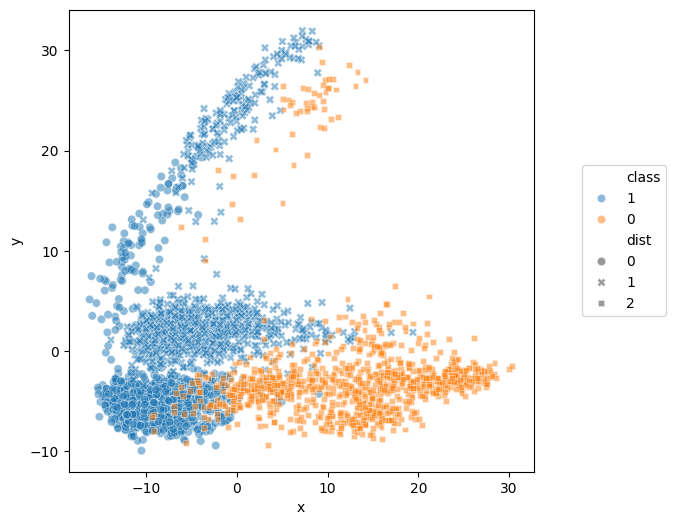

Example Triplet with Labels: [1, 1, 0]


In [ ]:

train_features, train_labels = next(iter(list(train_dataset.values())[0]))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")


trpl_distributions = train_features[0]
trpl_label = train_labels[0]


plot_distribution(trpl_distributions,trpl_label)

plt.show()
print(f"Example Triplet with Labels: {[l.item() for l in trpl_label]}")


In [ ]:
results = {}
thetas = {}
times = {}

In [ ]:
%load_ext autoreload
%autoreload 2

for a,l,t,k in train_dataset.keys():
    if (a,l,t,k) in times.keys():
        continue
    
    w_theta, time = ggml(train_dataset[(a,l,t,k)],a=a,l=l,k=k,lr=lr,max_iterations=iterations,plot_i_iterations=plot_every_i_iterations,dataset=training_data[(a,l,t,k)],save_i_iterations=save_every_i_iterations,n_threads=n_threads)

    thetas[(a,l,t,k)]= w_theta.clone().detach().numpy()
    times[(a,l,t,k)] = time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Running GGML with alpha: 1, lambda: 10, rank: 5


100%|██████████| 3/3 [11:31<00:00, 230.38s/it]


Iteration 1 with Loss  3365.361572265625


 33%|███▎      | 1/3 [04:24<08:49, 264.53s/it]

In [ ]:
import pandas as pd

(a,l,t,k) = list(times.keys())[0] #or specify other parameters
n_most_important = 10 
plot = False

reconstruct_m = False #default, considers each row in W
use_covs = False 

w_theta_npy = thetas[(a,l,t,k)]
components = range(k) if not reconstruct_m else [0] 

adata = sc.read_h5ad(dataset_folder+dataset_name)
gene_name = [gene for gene in adata.var['feature_name']]

for component in components:

    if reconstruct_m:
        w_theta_gene_space = np.dot(np.transpose(w_theta_npy),w_theta_npy)
    else:
        w_theta_gene_space = w_theta_npy[component,:]

    if use_covs and reconstruct_m:
        gene_pair_names = np.zeros((len(gene_name),len(gene_name)),dtype="object")
        for i, gene_i in enumerate(gene_name):
            for j, gene_j in enumerate(gene_name):
                if i == j:
                    gene_pair_names[i,j] = f"{gene_i}"
                else:
                    gene_pair_names[i,j] = f"{gene_i} x {gene_j}"

        flat_gene_importance = np.abs(w_theta_gene_space[np.triu_indices(len(w_theta_gene_space))].flatten())
        flat_gene_name = gene_pair_names[np.triu_indices(len(gene_pair_names))].flatten()
    else:
        if reconstruct_m:
            flat_gene_importance = np.abs(np.sum(w_theta_gene_space,axis=0))
        else:
            flat_gene_importance = w_theta_gene_space
        flat_gene_name = np.asarray(gene_name) 


    most_important_genes_ind = np.argsort(flat_gene_importance)[-n_most_important:]
    print(len(most_important_genes_ind))

    most_important_genes_names = flat_gene_name[most_important_genes_ind]

    average_importance = np.mean(flat_gene_importance)

    print(average_importance)
    most_important_genes_values = flat_gene_importance[most_important_genes_ind] / average_importance
    print(most_important_genes_values)

    sort_by_value =  np.flip(np.argsort(most_important_genes_values))



    if plot:
        gene_df = pd.DataFrame({'genes':most_important_genes_names[sort_by_value],'relative importance':most_important_genes_values[sort_by_value],'up/down':np.sign(most_important_genes_values[sort_by_value])})
        print("Df created")
        up_color = "lightsteelblue"
        down_color= "darkred"
        no_color = "grey"

        def addlabels(x,y,color=None):
            for i in range(len(y)):
                plt.text(x[i]//2, i, y[i], ha = 'center',color=color,verticalalignment ="center")

        plt.figure(figsize=(2,int(n_most_important *0.5)))
        sns.stripplot(gene_df, x="relative importance", y="genes", hue="up/down",legend=False,palette={-1:down_color,0:no_color,1:up_color})

        plt.figure(figsize=(3,int(n_most_important *0.7)))
        sns.barplot(gene_df, x="relative importance", y="genes", hue="up/down",legend=False,palette={-1:down_color,0:no_color,1:up_color})

        addlabels(most_important_genes_values[sort_by_value],most_important_genes_names[sort_by_value],color="black")
        plt.yticks([])
        plt.vlines(x = 1 , ymin=- 1/2,ymax= len(sort_by_value),color = 'black', label = 'axvline - full height',linestyles="dashed")
        plt.text(x = 1+0.3, y = len(sort_by_value)- 1/2, s="average",verticalalignment ="top") #rotation=90)

        plt.savefig(plt_path+f"feature_importance_{rank_k}_iter{i}.pdf")

    print(most_important_genes_values[sort_by_value])

    for i,gene_name in enumerate(np.flip(most_important_genes_names[sort_by_value])):   
        if " x " not in gene_name:
            pass #print(gene_name)

    import gprofiler  #https://pypi.org/project/gprofiler-official/
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np


    # In[22]:

    print(most_important_genes_names[sort_by_value])

    gp = gprofiler.GProfiler(return_dataframe=True)
    enrich = gp.profile(organism='hsapiens',
                query=list(np.flip(most_important_genes_names[sort_by_value])))
    enrich['NES'] = -np.log10(enrich['p_value'])
    #enrich.sort_index(axis=0,level='NES',inplace=True)
    #sns.barplot(x='NES',y='name',data=enrich,color='green') 
    
    plt.figure(figsize=(10,5))
    plt.subplots_adjust(left=0.5)
    sns.barplot(x='p_value',y='name',data=enrich,color='green')

    #g.get_figure().set_size_inches(5,5) 
    
    plt.savefig(plt_path+f"biological_process_submanifold_{component}.pdf")
    plt.show() 


In [ ]:
#Print average epoch time for different rank k and neighs. t
table = np.zeros((len(rank_k),len(neighbor_t)))

for a,l,t,k in times.keys():
    #print(f"Average time for neigh {t} and Rank {k} is {np.average(times[(a,l,t,k)])}")
    table[rank_k.index(k),neighbor_t.index(t)] = np.average(times[(a,l,t,k)])

table_df = pd.DataFrame(data=table,index=rank_k,columns=neighbor_t).transpose()


display(table_df)
print(table_df.to_latex(index=True,
                #formatters={"name": str.upper},
                float_format="{:.1f}".format,
))

[[1176.49686456]]


,5
3,1176.496865


\begin{tabular}{lr}
\toprule
 & 5 \\
\midrule
3 & 1176.5 \\
\bottomrule
\end{tabular}

